# Production-Grade Vastu 3D Room Visualization System
## Complete Pipeline: Any Video + Extended Vastu Rules

**New in this version:**
- Upload **any** video (mp4, mov, avi, mkv, webm, m4v) - Colab / Jupyter / manual path
- Expanded **Vastu rules for 50+ object types** with per-object rationale
- 5-panel depth visualisation (histogram, edge map)
- Detection heatmap aggregated across all frames
- Radar/spider compliance chart
- Zone-coloured 3D Matplotlib render
- Detailed HTML report export
- GLB / OBJ 3D model exports

**Run order:** Part 0 to Part 14 top to bottom.

## Part 0: Installation & Setup

In [ ]:
!pip install --upgrade pip -q
!pip install ultralytics timm opencv-python trimesh pyrender pygltflib \
             matplotlib numpy scipy pillow -q
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu -q
print('All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
All packages installed


## Part 1: Video Upload & Configuration

In [ ]:
import os, json, subprocess, random, datetime, pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from collections import defaultdict, Counter
import torch
import trimesh

SUPPORTED_EXTS = ('.mp4', '.mov', '.avi', '.mkv', '.webm', '.m4v')

def upload_video():
    # Google Colab
    try:
        from google.colab import files
        print('Google Colab detected. Upload your room video below.')
        print('Supported: ' + ', '.join(SUPPORTED_EXTS))
        uploaded = files.upload()
        if not uploaded: raise ValueError('No file uploaded.')
        filename = list(uploaded.keys())[0]
        if not filename.lower().endswith(SUPPORTED_EXTS):
            raise ValueError('Unsupported format: ' + filename)
        print('Uploaded: ' + filename + '  (' + str(round(len(uploaded[filename])/1e6,1)) + ' MB)')
        return filename
    except ImportError:
        pass
    # Jupyter Lab / Notebook
    try:
        import ipywidgets as widgets
        from IPython.display import display
        import time
        print('Jupyter detected. Use the button below to upload.')
        uploader = widgets.FileUpload(accept=','.join(SUPPORTED_EXTS), multiple=False,
                                      description='Upload Video', button_style='info',
                                      layout=widgets.Layout(width='280px'))
        status = widgets.Label(value='Waiting...')
        display(uploader, status)
        start = time.time()
        while not uploader.value and time.time() - start < 300:
            time.sleep(1)
        if not uploader.value: raise TimeoutError('Upload timed out (5 min).')
        fdata = list(uploader.value.values())[0]
        fname = fdata['metadata']['name']
        if not fname.lower().endswith(SUPPORTED_EXTS):
            raise ValueError('Unsupported format: ' + fname)
        with open(fname, 'wb') as f:
            f.write(fdata['content'])
        mb = round(len(fdata['content'])/1e6, 1)
        status.value = 'Saved: ' + fname + ' (' + str(mb) + ' MB)'
        print('Saved: ' + fname)
        return fname
    except ImportError:
        pass
    # Fallback: manual path
    print('No upload widget found.')
    path = input('Enter FULL path to your video file: ').strip().strip('"').strip("'")
    if not os.path.exists(path): raise FileNotFoundError('Not found: ' + path)
    if not path.lower().endswith(SUPPORTED_EXTS):
        raise ValueError('Unsupported format. Use: ' + str(SUPPORTED_EXTS))
    print('Video: ' + path)
    return path

VIDEO_PATH = upload_video()

FRAME_SAMPLE_RATE = 20
OUTPUT_DIR        = 'vastu_3d_results'
GA_GENERATIONS    = 100
GA_POPULATION     = 50
CAMERA_FOV        = 60

for d in [OUTPUT_DIR,
          OUTPUT_DIR+'/frames', OUTPUT_DIR+'/3d_models',
          OUTPUT_DIR+'/renders', OUTPUT_DIR+'/visualizations',
          OUTPUT_DIR+'/data']:
    os.makedirs(d, exist_ok=True)

print('Config ready')
print('  Video  : ' + VIDEO_PATH)
print('  Output : ' + OUTPUT_DIR + '/')
print('  Sample : every ' + str(FRAME_SAMPLE_RATE) + ' frames')

Google Colab detected. Upload your room video below.
Supported: .mp4, .mov, .avi, .mkv, .webm, .m4v


Saving Livingroom.mp4 to Livingroom.mp4
Uploaded: Livingroom.mp4  (27.0 MB)
Config ready
  Video  : Livingroom.mp4
  Output : vastu_3d_results/
  Sample : every 20 frames


## Part 2: Video Processing & Frame Extraction

Opening: Livingroom.mp4
1080x1920 30.0fps 36.1s [NORMAL]
Extracted 30 frames (every 20)


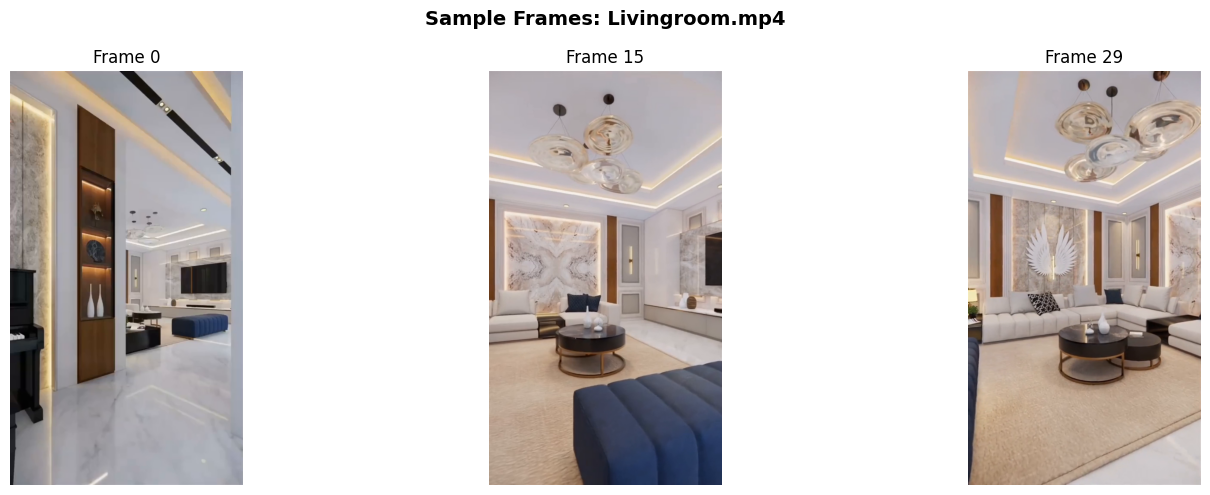

Frame extraction complete


In [ ]:
def extract_frames_robust(video_path, sample_rate=20, max_frames=50):
    if not os.path.exists(video_path):
        for c in [video_path, './'+video_path, os.path.join(os.getcwd(), video_path)]:
            if os.path.exists(c):
                video_path = c
                break
        else:
            raise FileNotFoundError('Video not found: ' + video_path)
    print('Opening: ' + video_path)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): raise ValueError('Cannot open video.')
    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if total == 0 or W == 0 or H == 0: raise ValueError('Invalid video.')
    ar      = W / H
    is_pano = ar > 1.8
    video_info = dict(fps=float(fps), total_frames=total, width=W, height=H,
                      aspect_ratio=ar, duration=total/fps if fps>0 else 0,
                      path=video_path, filename=os.path.basename(video_path),
                      is_panoramic=is_pano)
    print(str(W)+'x'+str(H)+' '+str(round(fps,1))+'fps '+str(round(video_info['duration'],1))+'s '+
          ('[PANORAMIC]' if is_pano else '[NORMAL]'))
    eff_rate = max(1, sample_rate//2) if is_pano else sample_rate
    frames, fid = [], 0
    while True:
        ret, frame = cap.read()
        if not ret or len(frames) >= max_frames: break
        if fid % eff_rate == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if is_pano:
                cw = int(H * 1.5)
                if cw < W:
                    sx = (W - cw) // 2
                    rgb = rgb[:, sx:sx+cw]
            frames.append(rgb)
        fid += 1
    cap.release()
    if not frames: raise ValueError('No frames extracted.')
    print('Extracted ' + str(len(frames)) + ' frames (every ' + str(eff_rate) + ')')
    return frames, video_info

frames, video_info = extract_frames_robust(VIDEO_PATH, FRAME_SAMPLE_RATE, max_frames=30)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sample Frames: ' + video_info['filename'], fontsize=14, fontweight='bold')
for i, idx in enumerate([0, len(frames)//2, -1]):
    axes[i].imshow(frames[idx])
    axes[i].set_title('Frame ' + str(idx if idx>=0 else len(frames)+idx))
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'/visualizations/01_sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print('Frame extraction complete')

## Part 3: Object Detection (YOLOv8)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLOv8n...
YOLOv8 loaded
Target categories: 35
Detecting in 30 frames...
  30/30...
Detected 99 instances
  couch               : 47
  chair               : 21
  tv                  : 16
  vase                : 10
  potted plant        : 4
  clock               : 1


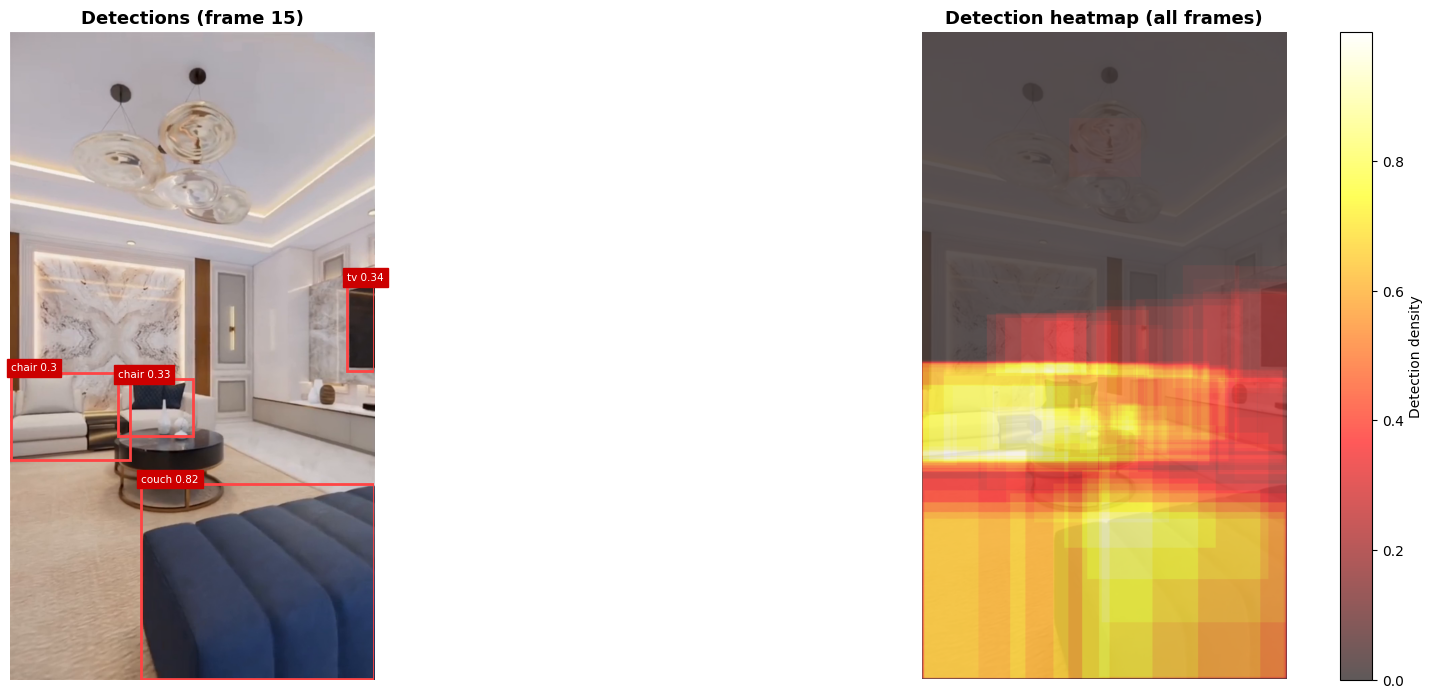

Heatmap saved


In [ ]:
from ultralytics import YOLO
print('Loading YOLOv8n...')
yolo_model = YOLO('yolov8n.pt')
print('YOLOv8 loaded')

ROOM_OBJECTS = {
    'bed', 'sofa', 'couch', 'chair', 'bench',
    'dining table', 'desk', 'cabinet',
    'refrigerator', 'oven', 'microwave', 'sink', 'toaster', 'kettle',
    'tv', 'laptop', 'computer', 'monitor', 'cell phone',
    'toilet', 'bathtub',
    'potted plant', 'vase', 'clock', 'mirror', 'book',
    'bicycle', 'umbrella', 'backpack', 'suitcase',
    'lamp', 'chandelier',
    'curtain', 'carpet', 'blanket',
}
print('Target categories: ' + str(len(ROOM_OBJECTS)))

def detect_objects_robust(frames, model, target_objects, confidence=0.3):
    all_dets = []
    print('Detecting in ' + str(len(frames)) + ' frames...')
    for idx, frame in enumerate(frames):
        if (idx+1) % 5 == 0: print('  ' + str(idx+1) + '/' + str(len(frames)) + '...', end='\r')
        try:
            for r in model(frame, conf=confidence, verbose=False):
                for box in r.boxes:
                    lbl = model.names[int(box.cls[0])]
                    if lbl not in target_objects: continue
                    x1,y1,x2,y2 = map(int, box.xyxy[0])
                    if x2>x1 and y2>y1:
                        all_dets.append(dict(frame_id=idx, label=lbl,
                                             bbox=[x1,y1,x2,y2],
                                             confidence=float(box.conf[0])))
        except Exception as e:
            print('  warn frame ' + str(idx) + ': ' + str(e))
    print('\nDetected ' + str(len(all_dets)) + ' instances')
    for obj, n in Counter(d['label'] for d in all_dets).most_common():
        print('  ' + obj.ljust(20) + ': ' + str(n))
    return all_dets

detections = detect_objects_robust(frames, yolo_model, ROOM_OBJECTS)

if detections:
    H0, W0, _ = frames[0].shape
    heatmap = np.zeros((H0, W0), dtype=np.float32)
    for d in detections:
        x1,y1,x2,y2 = d['bbox']
        x1,y1,x2,y2 = max(0,x1),max(0,y1),min(W0,x2),min(H0,y2)
        heatmap[y1:y2, x1:x2] += d['confidence']
    heatmap /= (heatmap.max() + 1e-6)
    mid = len(frames)//2
    frame_dets = [d for d in detections if d['frame_id']==mid]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    ax1.imshow(frames[mid].copy())
    for d in frame_dets:
        x1,y1,x2,y2 = d['bbox']
        ax1.add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor='#ff4444',lw=2))
        ax1.text(x1, max(0,y1-6), d['label']+' '+str(round(d['confidence'],2)),
                 color='white', backgroundcolor='#cc0000', fontsize=7.5)
    ax1.set_title('Detections (frame ' + str(mid) + ')', fontsize=13, fontweight='bold')
    ax1.axis('off')
    ax2.imshow(frames[mid], alpha=0.45)
    im = ax2.imshow(heatmap, cmap='hot', alpha=0.65)
    plt.colorbar(im, ax=ax2, fraction=0.036, label='Detection density')
    ax2.set_title('Detection heatmap (all frames)', fontsize=13, fontweight='bold')
    ax2.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'/visualizations/02_detections_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Heatmap saved')
else:
    print('No detections.')

## Part 4: Depth Estimation (MiDaS v3.1)

Loading MiDaS...
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:16<00:00, 84.7MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


MiDaS ready on cpu
Estimating depth (~30 s)...
Depth map (1920, 1080)  range [2.61, 44.13]


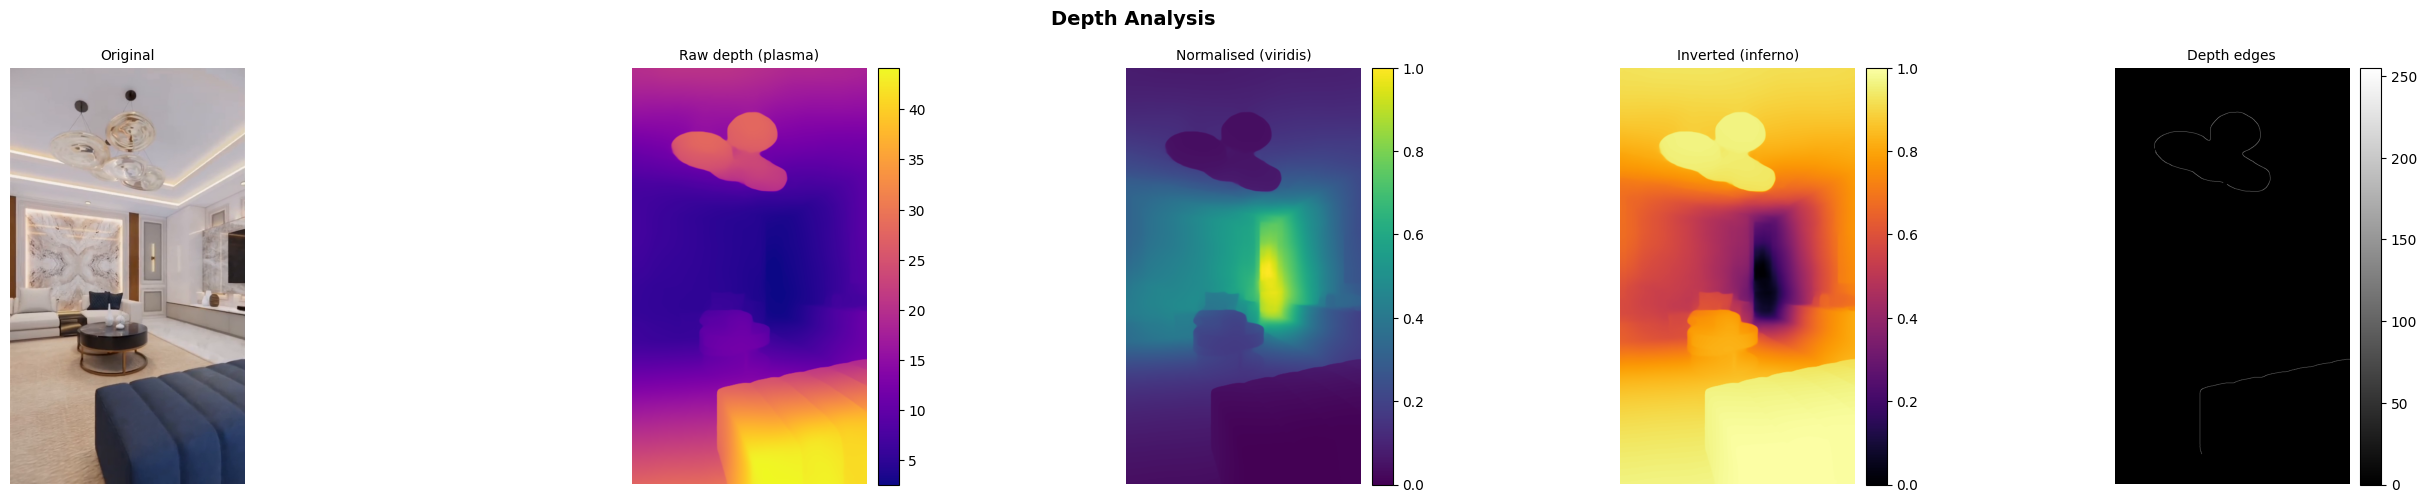

Depth visualisation saved


In [ ]:
print('Loading MiDaS...')
try:
    midas     = torch.hub.load('intel-isl/MiDaS', 'DPT_Large', trust_repo=True)
    midas_tr  = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
    transform = midas_tr.dpt_transform
except Exception as e:
    print('DPT_Large failed (' + str(e) + '), using MiDaS_small...')
    midas     = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True)
    midas_tr  = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
    transform = midas_tr.small_transform
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
midas.to(device).eval()
print('MiDaS ready on ' + str(device))

def estimate_depth(image, model, tfm, dev):
    try:
        with torch.no_grad():
            pred = model(tfm(image).to(dev))
            pred = torch.nn.functional.interpolate(
                pred.unsqueeze(1), size=image.shape[:2],
                mode='bicubic', align_corners=False).squeeze()
        dm = pred.cpu().numpy()
        return np.nan_to_num(dm, nan=0., posinf=0., neginf=0.)
    except Exception as e:
        print('  depth error: ' + str(e))
        return np.ones(image.shape[:2]) * 0.5

print('Estimating depth (~30 s)...')
rep_frame = frames[len(frames)//2]
depth_map = estimate_depth(rep_frame, midas, transform, device)
print('Depth map ' + str(depth_map.shape) + '  range [' +
      str(round(depth_map.min(),2)) + ', ' + str(round(depth_map.max(),2)) + ']')

dn = 1.0/(depth_map+1e-6)
dn = (dn-dn.min())/(dn.max()-dn.min())
edges = cv2.Canny(((depth_map-depth_map.min())/(depth_map.max()-depth_map.min())*255).astype(np.uint8), 50, 150)
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('Depth Analysis', fontsize=14, fontweight='bold')
data5  = [rep_frame, depth_map, dn, 1-dn, edges]
titles = ['Original', 'Raw depth (plasma)', 'Normalised (viridis)', 'Inverted (inferno)', 'Depth edges']
cmaps5 = [None, 'plasma', 'viridis', 'inferno', 'gray']
for ax, img, ttl, cmap in zip(axes, data5, titles, cmaps5):
    im = ax.imshow(img, cmap=cmap)
    ax.set_title(ttl, fontsize=10); ax.axis('off')
    if cmap: plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'/visualizations/03_depth_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Depth visualisation saved')

## Part 5: Feature Extraction & Stabilisation

In [ ]:
IMG_H, IMG_W, _ = frames[0].shape
print('Image: ' + str(IMG_W) + 'x' + str(IMG_H))

for obj in detections:
    x1,y1,x2,y2 = obj['bbox']
    cx = (x1+x2)/2; cy = (y1+y2)/2
    obj['cx_norm']   = float(np.clip(cx/IMG_W, 0, 1))
    obj['cy_norm']   = float(np.clip(cy/IMG_H, 0, 1))
    obj['area_norm'] = float((x2-x1)*(y2-y1)/(IMG_W*IMG_H))
    obj['cx_pixel']  = float(cx)
    obj['cy_pixel']  = float(cy)

object_detections = defaultdict(list)
for obj in detections:
    object_detections[obj['label']].append(
        (obj['cx_norm'], obj['cy_norm'], obj['area_norm'], obj['cx_pixel'], obj['cy_pixel']))

stabilized_objects = {}
for label, dl in object_detections.items():
    top = sorted(dl, key=lambda x: x[2], reverse=True)[:5]
    stabilized_objects[label] = dict(
        cx=float(np.mean([d[0] for d in top])),
        cy=float(np.mean([d[1] for d in top])),
        area=float(np.mean([d[2] for d in top])),
        cx_pixel=float(np.mean([d[3] for d in top])),
        cy_pixel=float(np.mean([d[4] for d in top])))

print('Stabilised ' + str(len(stabilized_objects)) + ' objects:')
for obj, d in stabilized_objects.items():
    print('  ' + obj.ljust(22) + ': (' + str(round(d['cx'],3)) + ', ' + str(round(d['cy'],3)) + ')')

Image: 1080x1920
Stabilised 6 objects:
  vase                  : (0.69, 0.592)
  tv                    : (0.789, 0.475)
  couch                 : (0.493, 0.864)
  chair                 : (0.643, 0.686)
  potted plant          : (0.765, 0.507)
  clock                 : (0.501, 0.18)


## Part 6: 3D Coordinate Extraction

In [ ]:
def estimate_camera_params(W, H, fov=60, is_panoramic=False):
    if is_panoramic: fov = 120; print('  Panoramic -> FOV 120 deg')
    fx = W / (2 * np.tan(np.radians(fov) / 2))
    return dict(fx=float(fx), fy=float(fx), cx=float(W/2), cy=float(H/2),
                width=W, height=H, fov=fov, is_panoramic=is_panoramic)

camera_params = estimate_camera_params(IMG_W, IMG_H, CAMERA_FOV,
                                       is_panoramic=video_info.get('is_panoramic', False))
print('Camera: fx=' + str(round(camera_params['fx'],1)) + 'px  FOV=' + str(camera_params['fov']) + ' deg')

def get_depth_at(cx_px, cy_px, dm, margin=15):
    H, W = dm.shape
    y1,y2 = max(0,int(cy_px-margin)), min(H,int(cy_px+margin))
    x1,x2 = max(0,int(cx_px-margin)), min(W,int(cx_px+margin))
    return np.median(dm[y1:y2, x1:x2]) if y2>y1 and x2>x1 else dm[int(cy_px),int(cx_px)]

def pixel_to_3d(cx_px, cy_px, dv, cam):
    di = 1.0/(dv+1e-6)
    dn = (di-depth_map.min())/(depth_map.max()-depth_map.min()+1e-6)
    Z  = 2.0 + dn*6.0
    return float((cx_px-cam['cx'])*Z/cam['fx']), float((cy_px-cam['cy'])*Z/cam['fy']), float(Z)

objects_3d = {}
print('Extracting 3D coordinates...')
for name, d in stabilized_objects.items():
    dv = get_depth_at(d['cx_pixel'], d['cy_pixel'], depth_map)
    X,Y,Z = pixel_to_3d(d['cx_pixel'], d['cy_pixel'], dv, camera_params)
    objects_3d[name] = dict(position_3d=(X,Y,Z), position_2d=(d['cx'],d['cy']),
                             depth_value=float(dv))
    print('  ' + name.ljust(22) + ': (' + str(round(X,2)) + ', ' + str(round(Y,2)) + ', ' + str(round(Z,2)) + ') m')
print('3D coordinates extracted')

Camera: fx=935.3px  FOV=60 deg
Extracting 3D coordinates...
  vase                  : (0.37, 0.32, 1.66) m
  tv                    : (0.55, -0.08, 1.65) m
  couch                 : (-0.01, 1.22, 1.63) m
  chair                 : (0.27, 0.63, 1.64) m
  potted plant          : (0.51, 0.02, 1.66) m
  clock                 : (0.0, -1.07, 1.63) m
3D coordinates extracted


## Part 7: Vastu Rules — Full Object Coverage

Defines Vastu zone rules **and rationale** for every detectable object category:
furniture, decor, kitchen, bathroom, electronics, textiles, outdoor.

Vastu rules loaded for 35 object types
Zone assignments:
  vase                   -> East
  tv                     -> East
  couch                  -> South
  chair                  -> South
  potted plant           -> East
  clock                  -> North

CURRENT LAYOUT - VASTU COMPLIANCE
[OK] vase                 in East           
[OK] tv                   in East           
[XX] couch                in South            -> should be: North, North-East, East, West
[XX] chair                in South            -> should be: West, East, North, North-West
[OK] potted plant         in East           
[OK] clock                in North          

Violations : 2/6
Compliance : 66.7%


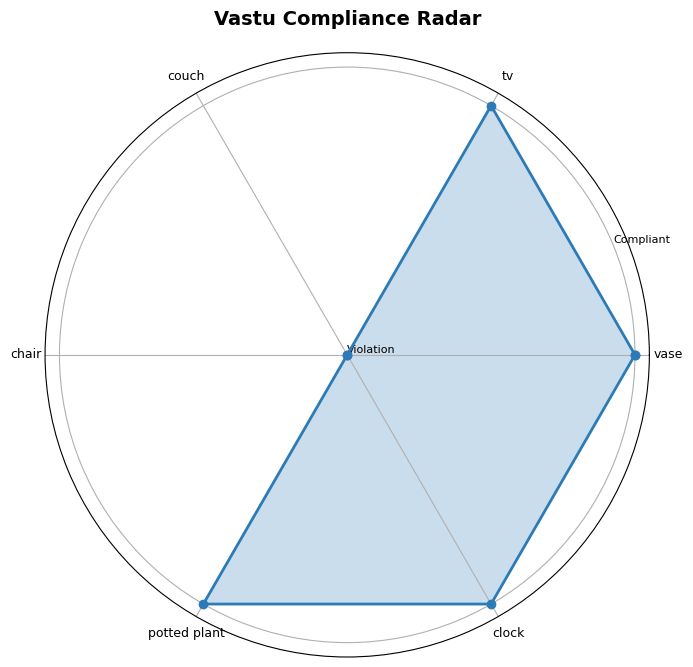

Radar chart saved


In [ ]:
# ============================================================
# VASTU_RULES_FULL  - zones + rationale per object type
# Zones: North/South/East/West/Center
#        North-East/North-West/South-East/South-West
# Sources: Manasara, Mayamata & contemporary Vastu practice
# ============================================================

VASTU_RULES_FULL = {

    # ---- SEATING & SLEEPING ------------------------------------
    'bed': {
        'zones': ['South-West', 'South', 'West'],
        'rationale': (
            'South-West (Nairutya) is the stabilising Earth corner. '
            'Sleeping with head toward South/West aligns with Earth magnetism '
            'for deep, restorative sleep. Avoid North - magnetic pull causes restlessness.'
        )
    },
    'sofa': {
        'zones': ['North', 'North-East', 'East', 'West'],
        'rationale': (
            'Lightweight upholstered seating belongs in the lighter Northern arc. '
            'North-East (Ishanya) invites divine prosperity energy into the sitting area. '
            'South-West is reserved for heavy structural furniture only.'
        )
    },
    'couch': {
        'zones': ['North', 'North-East', 'East', 'West'],
        'rationale': (
            'Same as sofa. Couches are lighter seating and should remain in '
            'the energetically active Northern arc to promote conversation and positivity.'
        )
    },
    'chair': {
        'zones': ['West', 'East', 'North', 'North-West'],
        'rationale': (
            'Work chairs face East (rising Sun, concentration) or North (Kuber, prosperity). '
            'West is acceptable for reading where natural light falls from behind. '
            'North-West (Vayavya) supports movement and dynamic activity.'
        )
    },
    'bench': {
        'zones': ['East', 'North', 'West'],
        'rationale': (
            'Open benches carry the same energy as chairs. East for focus, '
            'North for prosperity flow. Avoid South-West to keep the Earth corner '
            'free for heavier, anchoring furniture.'
        )
    },

    # ---- TABLES & STORAGE -------------------------------------
    'dining table': {
        'zones': ['West', 'North-West'],
        'rationale': (
            'West (Varun - water/prosperity) governs nourishment. '
            'North-West (Vayavya) supports movement and healthy digestion. '
            'Eating here aligns meal energy with prosperity and gratitude.'
        )
    },
    'desk': {
        'zones': ['East', 'North', 'North-East'],
        'rationale': (
            'East faces the rising Sun - ideal for study and work desks. '
            'North (Kuber) brings professional success. '
            'North-East (Ishanya) is the zone of intellect and knowledge in Vastu.'
        )
    },
    'cabinet': {
        'zones': ['South-West', 'South', 'West'],
        'rationale': (
            'Heavy storage cabinets must sit in South-West to ground the space. '
            'South wall storage is also acceptable. '
            'Never place heavy cabinets in North-East - this blocks sacred energy flow.'
        )
    },

    # ---- KITCHEN APPLIANCES -----------------------------------
    'refrigerator': {
        'zones': ['South-East', 'South', 'West'],
        'rationale': (
            'South-East (Agni corner) governs all appliances. '
            'Though the fridge is cool, it runs on electricity (fire element). '
            'Placing it here balances fire-water polarity in the kitchen. '
            'Never place in North-East (sacred water zone).'
        )
    },
    'oven': {
        'zones': ['South-East'],
        'rationale': (
            'The oven is quintessential Agni (fire). '
            'South-East is the fire corner in every classical Vastu text. '
            'Cooking here amplifies food energy and digestion quality.'
        )
    },
    'microwave': {
        'zones': ['South-East', 'South'],
        'rationale': (
            'A fire-element appliance - same prescription as oven. '
            'South-East (Agni corner) or South keeps electromagnetic '
            'and thermal energy properly contained.'
        )
    },
    'sink': {
        'zones': ['North-East', 'North', 'East'],
        'rationale': (
            'North-East is the Jal (water) zone. Sinks and wash basins here '
            'ensure water flows in an auspicious direction (out through North/East). '
            'Water energy in this quadrant invites prosperity and health.'
        )
    },
    'toaster': {
        'zones': ['South-East', 'South'],
        'rationale': (
            'Fire-element small appliance. Same as oven: South-East contains '
            'and amplifies the Agni energy appropriately.'
        )
    },
    'kettle': {
        'zones': ['South-East', 'South'],
        'rationale': (
            'Though a kettle heats water, its heating element makes it a fire appliance. '
            'South-East placement harnesses Agni energy for quick, nourishing heat.'
        )
    },

    # ---- ELECTRONICS ------------------------------------------
    'tv': {
        'zones': ['East', 'South-East'],
        'rationale': (
            'TV faces East so viewers face West (auspicious viewing direction). '
            'South-East also acceptable as screens emit electromagnetic energy '
            'that aligns well with the Agni corner.'
        )
    },
    'laptop': {
        'zones': ['East', 'North', 'North-East'],
        'rationale': (
            'Portable work device - follows desk rules. East for focus, '
            'North for professional success, North-East for creative output.'
        )
    },
    'computer': {
        'zones': ['East', 'North'],
        'rationale': (
            'Desktop computers represent sustained work energy. '
            'East (Sun - concentration) and North (Kuber - career success) are ideal.'
        )
    },
    'monitor': {
        'zones': ['East', 'North'],
        'rationale': (
            'Same as desktop - the display is part of the workspace. '
            'East/North placement maximises productivity and success energy.'
        )
    },
    'cell phone': {
        'zones': ['East', 'North', 'North-East'],
        'rationale': (
            'Mobile charging stations should occupy the knowledge zone '
            '(North-East/North/East) to infuse communication with positive energy.'
        )
    },

    # ---- BATHROOM ---------------------------------------------
    'toilet': {
        'zones': ['West', 'North-West', 'South'],
        'rationale': (
            'Toilets discharge waste energy and must never be in North-East (sacred) '
            'or South-West (master stabilising corner). '
            'West and North-West are the prescribed zones in all classical texts.'
        )
    },
    'bathtub': {
        'zones': ['East', 'North-East', 'North'],
        'rationale': (
            'Bathing is a purification ritual. East (dawn, renewal) and '
            'North-East (sacred water) are ideal. Water flowing out toward '
            'these directions is considered auspicious.'
        )
    },

    # ---- DECOR & ACCESSORIES ----------------------------------
    'potted plant': {
        'zones': ['North-East', 'East', 'North'],
        'rationale': (
            'Living plants represent growth and Prana (life force). '
            'North-East and East provide morning Sun, stimulating plant vitality. '
            'Avoid South-West - plants there drain Earth energy and can cause lethargy.'
        )
    },
    'vase': {
        'zones': ['East', 'North-East', 'North'],
        'rationale': (
            'Vases hold water and flowers (Jal element). '
            'North-East, North, and East are the water/prosperity zones. '
            'Fill with fresh flowers for maximum positive energy flow.'
        )
    },
    'clock': {
        'zones': ['North', 'East', 'North-East'],
        'rationale': (
            'Clocks represent time flow and should not be in inauspicious zones. '
            'North (Kuber) and East (movement/Sun) are ideal. '
            'South wall clocks are considered inauspicious - they face descending time.'
        )
    },
    'mirror': {
        'zones': ['North', 'East'],
        'rationale': (
            'Mirrors double whatever energy they reflect. '
            'North wall mirrors double prosperity (Kuber). '
            'East mirrors double morning light and positive energy. '
            'Avoid South - they reflect and amplify negative downward energy.'
        )
    },
    'book': {
        'zones': ['East', 'North-East', 'North'],
        'rationale': (
            'Books represent knowledge (Goddess Saraswati). '
            'North-East (Ishanya) and East are zones of intellect and learning. '
            'Placing books here honours knowledge and attracts wisdom.'
        )
    },

    # ---- LIGHTING ---------------------------------------------
    'lamp': {
        'zones': ['South-East', 'East', 'North-East'],
        'rationale': (
            'Lamps represent Agni (fire/light). South-East is the primary fire corner. '
            'East-facing lamps symbolise the rising Sun and new beginnings. '
            'Avoid South-West - fire there aggravates conflict and instability.'
        )
    },
    'chandelier': {
        'zones': ['Center'],
        'rationale': (
            'The chandelier belongs at the Brahmasthan (sacred center). '
            'Central placement disperses light equally to all eight directions, '
            'energising the entire home uniformly.'
        )
    },

    # ---- TEXTILES ---------------------------------------------
    'curtain': {
        'zones': ['East', 'North', 'West'],
        'rationale': (
            'Curtains regulate light and privacy. East and North curtains should '
            'be light-coloured and thin to allow morning energy in. '
            'West curtains can be heavier to manage afternoon heat.'
        )
    },
    'carpet': {
        'zones': ['Center', 'East', 'North'],
        'rationale': (
            'A carpet at the Brahmasthan (Center) anchors and stabilises room energy. '
            'East and North carpets invite positive energy flow at entry points.'
        )
    },
    'blanket': {
        'zones': ['South-West', 'South'],
        'rationale': (
            'Blankets are associated with rest and the bed zone. '
            'Store or use them in South-West (stability/rest corner) '
            'for deep, undisturbed sleep.'
        )
    },

    # ---- OUTDOOR / TRANSIT ------------------------------------
    'bicycle': {
        'zones': ['West', 'North-West'],
        'rationale': (
            'Vehicles represent movement (Vayu - wind element). '
            'North-West (Vayavya - wind deity) is ideal for all moving objects. '
            'Storing a bicycle here encourages regular use and healthy movement.'
        )
    },
    'umbrella': {
        'zones': ['West', 'North-West', 'East'],
        'rationale': (
            'Umbrellas represent shelter and rain (Jal). '
            'North-West (wind) or near the entrance (East/North) are practical '
            'and energetically appropriate in Vastu.'
        )
    },
    'backpack': {
        'zones': ['West', 'North-West'],
        'rationale': (
            'Travel bags belong in the zone of movement (North-West). '
            'Storing a backpack in South-West (Earth stability) anchors you '
            'energetically and subconsciously discourages travel and exploration.'
        )
    },
    'suitcase': {
        'zones': ['West', 'North-West'],
        'rationale': (
            'Same as backpack. Luggage stored in North-West activates travel '
            'energy and ensures smooth, auspicious journeys.'
        )
    },
}

# Compact zone-only dict for GA fitness
VASTU_RULES = {obj: v['zones'] for obj, v in VASTU_RULES_FULL.items()}

print('Vastu rules loaded for ' + str(len(VASTU_RULES)) + ' object types')

# Zone assignment
def get_vastu_zone(cx, cy):
    v = 'North' if cy < 0.33 else ('Center' if cy < 0.66 else 'South')
    h = 'West'  if cx < 0.33 else ('Center' if cx < 0.66 else 'East')
    if v == 'Center' and h == 'Center': return 'Center'
    if v == 'Center': return h
    if h == 'Center': return v
    return v + '-' + h

def coords_to_zone(cx, cy): return get_vastu_zone(cx, cy)

for obj, d in stabilized_objects.items():
    d['zone'] = get_vastu_zone(d['cx'], d['cy'])
    objects_3d[obj]['zone'] = d['zone']

print('Zone assignments:')
for obj, d in stabilized_objects.items():
    print('  ' + obj.ljust(22) + ' -> ' + d['zone'])

# Compliance check
def check_compliance(objects, rules):
    results, viol = [], 0
    for obj, d in objects.items():
        zone    = d['zone']
        allowed = rules.get(obj, [])
        ok      = zone in allowed if allowed else True
        if not ok: viol += 1
        results.append(dict(object=obj, zone=zone, allowed=allowed, compliant=ok))
    return results, viol

compliance, violations = check_compliance(stabilized_objects, VASTU_RULES)

print('\n' + '='*65)
print('CURRENT LAYOUT - VASTU COMPLIANCE')
print('='*65)
for item in compliance:
    s = 'OK' if item['compliant'] else 'XX'
    line = '[' + s + '] ' + item['object'].ljust(20) + ' in ' + item['zone'].ljust(15)
    if not item['compliant'] and item['allowed']:
        line += '  -> should be: ' + ', '.join(item['allowed'])
    print(line)
n_obj = max(len(stabilized_objects), 1)
print('\nViolations : ' + str(violations) + '/' + str(len(stabilized_objects)))
print('Compliance : ' + str(round((1-violations/n_obj)*100, 1)) + '%')
print('='*65)

# Radar chart
objs_list   = [c['object'] for c in compliance]
compliant_v = [1 if c['compliant'] else 0 for c in compliance]
if len(objs_list) >= 3:
    angles = np.linspace(0, 2*np.pi, len(objs_list), endpoint=False).tolist()
    vals   = compliant_v + [compliant_v[0]]
    ang    = angles + angles[:1]
    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(7,7))
    ax.plot(ang, vals, 'o-', linewidth=2, color='#2c7bb6')
    ax.fill(ang, vals, alpha=0.25, color='#2c7bb6')
    ax.set_xticks(angles)
    ax.set_xticklabels(objs_list, size=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Violation','Compliant'], size=8)
    ax.set_title('Vastu Compliance Radar', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'/visualizations/04_compliance_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Radar chart saved')

## Part 8: Genetic Algorithm Optimisation

GA: 100 gen x 50 pop...
  Gen 20: fitness=0.37
  Gen 40: fitness=0.259
  Gen 60: fitness=0.235
  Gen 80: fitness=0.218
  Gen 100: fitness=0.212
GA done | 10.375 -> 0.212  (delta 10.163)


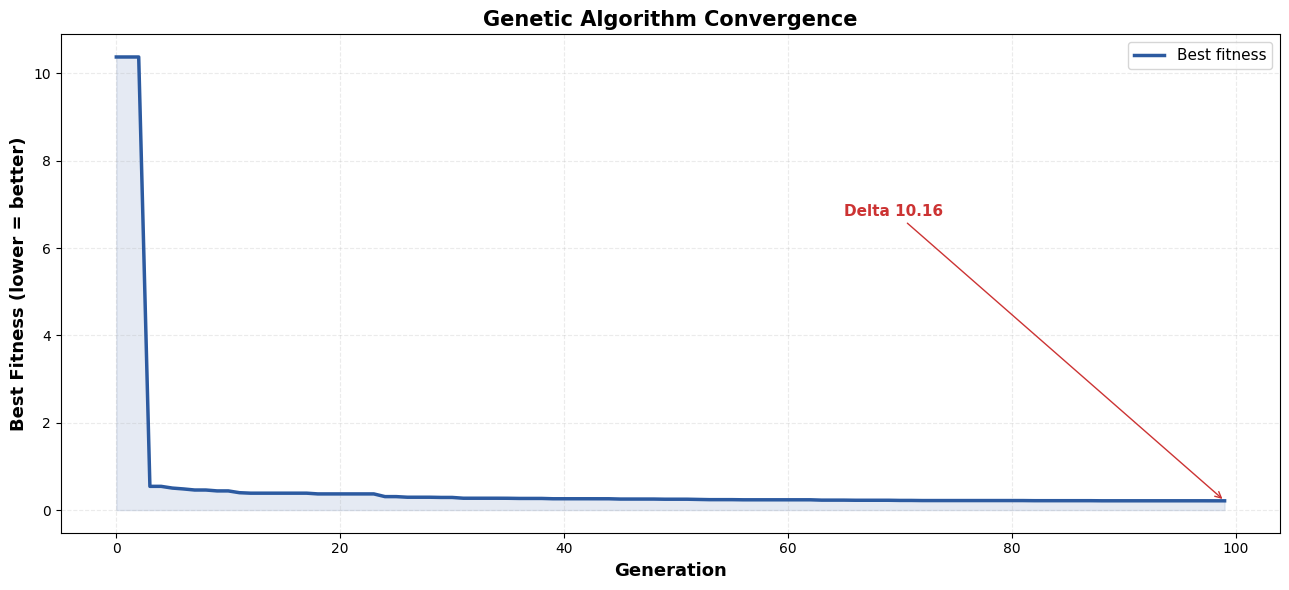

Convergence saved  (improvement: 10.16)
Optimised violations: 0/6  (100.0% compliant)


In [ ]:
def init_population(objects, pop_size=50):
    return [{obj:(random.random(), random.random()) for obj in objects}
            for _ in range(pop_size)]

def mutate(ind, rate=0.3, sigma=0.15):
    new = ind.copy()
    for obj in new:
        if random.random() < rate:
            cx,cy = new[obj]
            new[obj] = (float(np.clip(cx+random.gauss(0,sigma),0,1)),
                        float(np.clip(cy+random.gauss(0,sigma),0,1)))
    return new

def crossover(p1, p2):
    return {obj: p1[obj] if random.random()<0.5 else p2[obj] for obj in p1}

def calculate_fitness(layout, original, rules):
    vp = sum(10 for obj,(cx,cy) in layout.items()
             if rules.get(obj) and coords_to_zone(cx,cy) not in rules[obj])
    mp = sum(0.2*np.sqrt((cx-original[obj]['cx'])**2+(cy-original[obj]['cy'])**2)
             for obj,(cx,cy) in layout.items())
    pos = list(layout.items())
    op  = sum(5 for i in range(len(pos)) for j in range(i+1,len(pos))
              if np.sqrt((pos[i][1][0]-pos[j][1][0])**2+(pos[i][1][1]-pos[j][1][1])**2)<0.15)
    return vp+mp+op

def run_ga(orig, rules, generations=100, pop_size=50):
    print('GA: ' + str(generations) + ' gen x ' + str(pop_size) + ' pop...')
    pop  = init_population(orig.keys(), pop_size)
    hist = []
    for gen in range(generations):
        scored = sorted([(ind, calculate_fitness(ind,orig,rules)) for ind in pop],
                        key=lambda x:x[1])
        pop  = [ind for ind,_ in scored]
        hist.append(scored[0][1])
        if (gen+1)%20==0: print('  Gen ' + str(gen+1) + ': fitness=' + str(round(hist[-1],3)))
        parents = pop[:max(1,int(0.3*pop_size))]
        new_pop = parents[:]
        while len(new_pop)<pop_size:
            new_pop.append(mutate(crossover(random.choice(parents),random.choice(parents))))
        pop = new_pop
    final     = [(ind,calculate_fitness(ind,orig,rules)) for ind in pop]
    best,score = min(final, key=lambda x:x[1])
    print('GA done | ' + str(round(hist[0],3)) + ' -> ' + str(round(score,3)) +
          '  (delta ' + str(round(hist[0]-score,3)) + ')')
    return best, hist

optimized_layout, fitness_history = run_ga(
    stabilized_objects, VASTU_RULES, GA_GENERATIONS, GA_POPULATION)

# Convergence chart
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(fitness_history, linewidth=2.5, color='#2c5aa0', label='Best fitness')
ax.fill_between(range(len(fitness_history)), fitness_history, alpha=0.12, color='#2c5aa0')
improvement = fitness_history[0] - fitness_history[-1]
ax.annotate('Delta ' + str(round(improvement,2)),
            xy=(len(fitness_history)-1, fitness_history[-1]),
            xytext=(len(fitness_history)*0.65, fitness_history[0]*0.65),
            arrowprops=dict(arrowstyle='->', color='#cc3333'),
            fontsize=11, color='#cc3333', fontweight='bold')
ax.set_xlabel('Generation', fontsize=13, fontweight='bold')
ax.set_ylabel('Best Fitness (lower = better)', fontsize=13, fontweight='bold')
ax.set_title('Genetic Algorithm Convergence', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'/visualizations/05_ga_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Convergence saved  (improvement: ' + str(round(improvement,2)) + ')')

# Convert to 3D
optimized_objects_3d = {}
for name,(cx,cy) in optimized_layout.items():
    px,py = cx*IMG_W, cy*IMG_H
    dv    = get_depth_at(px, py, depth_map)
    X,Y,Z = pixel_to_3d(px, py, dv, camera_params)
    optimized_objects_3d[name] = dict(
        position_3d=(X,Y,Z), position_2d=(cx,cy),
        zone=coords_to_zone(cx,cy), depth_value=float(dv))

opt_check = {o:{'zone':d['zone']} for o,d in optimized_objects_3d.items()}
opt_compliance, opt_violations = check_compliance(opt_check, VASTU_RULES)
print('Optimised violations: ' + str(opt_violations) + '/' + str(len(opt_check)) +
      '  (' + str(round((1-opt_violations/max(len(opt_check),1))*100,1)) + '% compliant)')

## Part 9: 2D Layout Visualisation (Before / After)

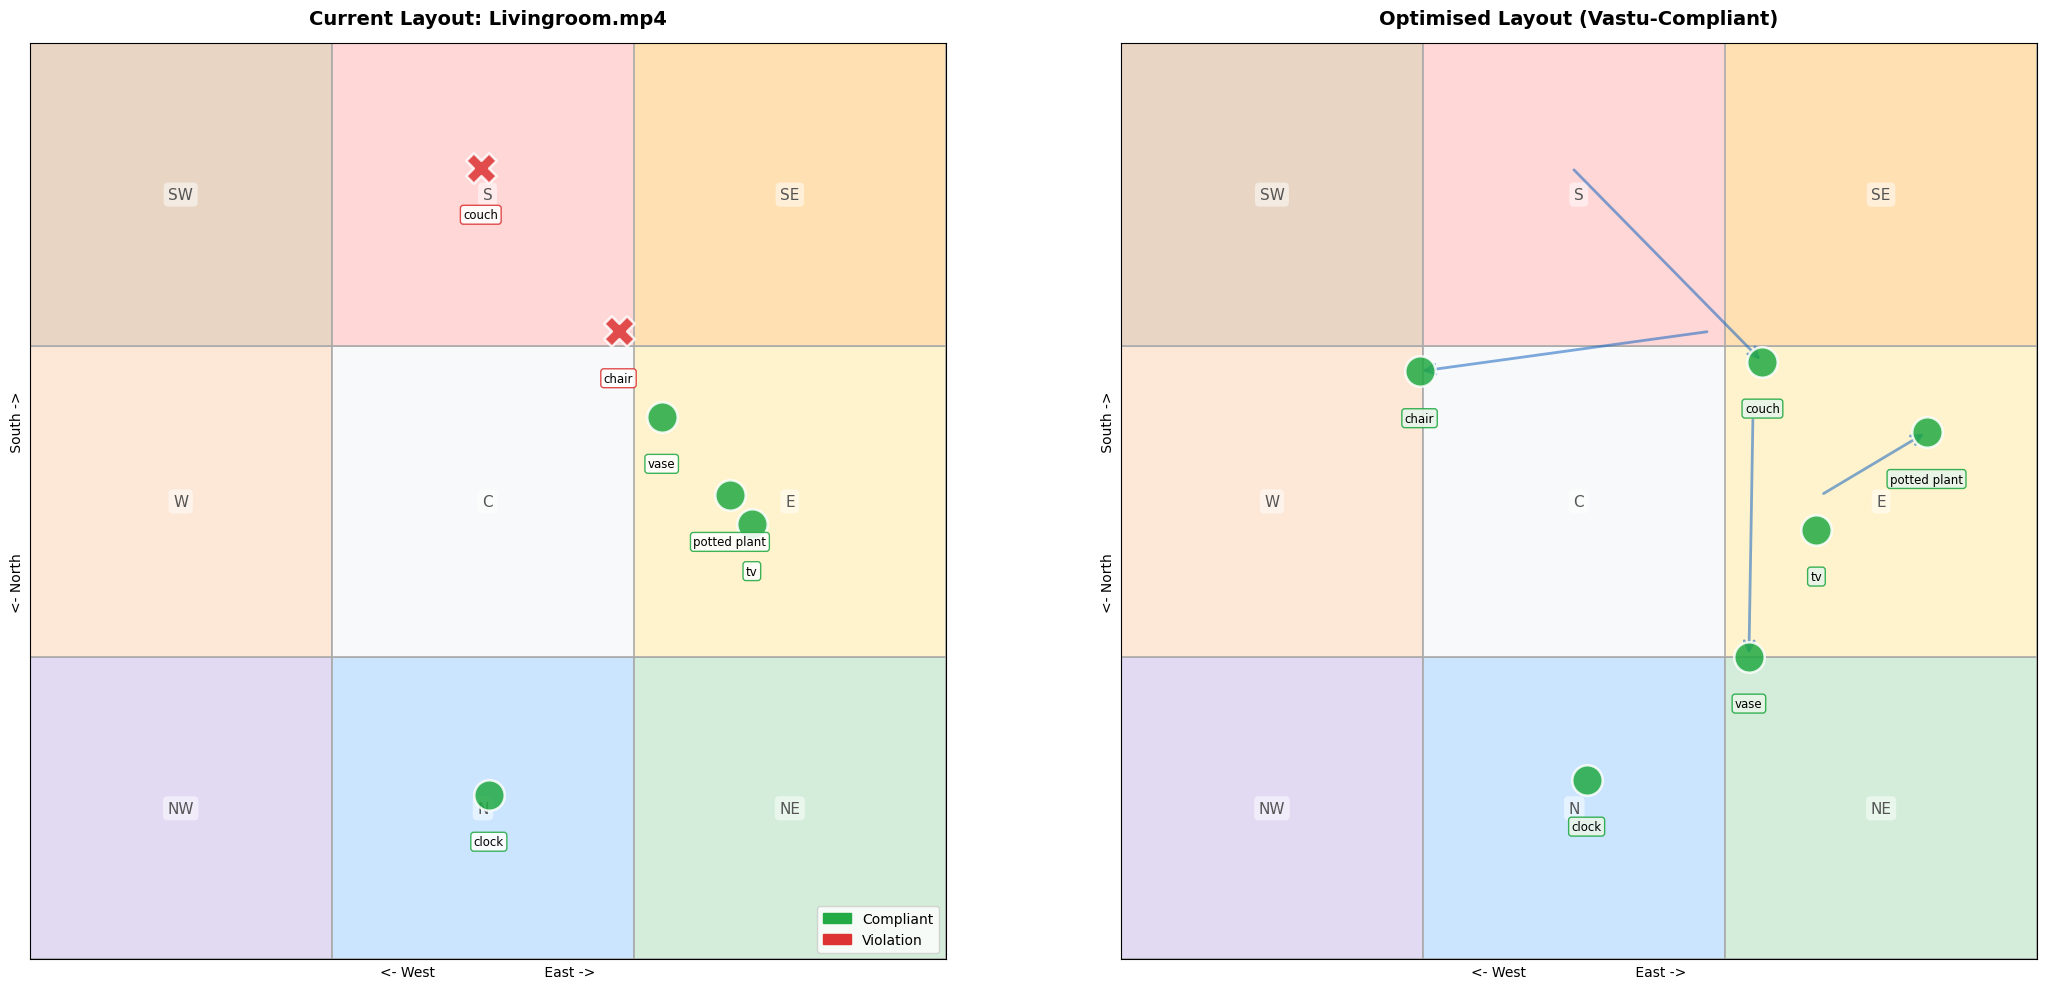

2D comparison saved


In [ ]:
ZONE_COLORS = {
    'North-East': '#d4edda', 'North': '#cce5ff', 'North-West': '#e2d9f3',
    'East': '#fff3cd', 'Center': '#f8f9fa', 'West': '#fde8d8',
    'South-East': '#ffe0b2', 'South': '#ffd7d7', 'South-West': '#e8d5c4',
}
ZONE_GRID = [
    ('North-West', 0,    0,    0.33, 0.33),
    ('North',      0.33, 0,    0.33, 0.33),
    ('North-East', 0.66, 0,    0.34, 0.33),
    ('West',       0,    0.33, 0.33, 0.34),
    ('Center',     0.33, 0.33, 0.34, 0.34),
    ('East',       0.66, 0.33, 0.34, 0.34),
    ('South-West', 0,    0.67, 0.33, 0.33),
    ('South',      0.33, 0.67, 0.34, 0.33),
    ('South-East', 0.66, 0.67, 0.34, 0.33),
]
ZONE_SHORT = {'North-East':'NE','North-West':'NW','South-East':'SE','South-West':'SW',
              'North':'N','South':'S','East':'E','West':'W','Center':'C'}

def draw_vastu_grid(ax, title):
    for zone, x, y, w, h in ZONE_GRID:
        ax.add_patch(plt.Rectangle((x,y),w,h,
                     facecolor=ZONE_COLORS.get(zone,'#ffffff'),
                     edgecolor='#aaaaaa', linewidth=1.2, zorder=1))
        ax.text(x+w/2, y+h/2, ZONE_SHORT.get(zone,zone), ha='center', va='center',
                fontsize=11, color='#555555', zorder=2,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5, ec='none'))
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel('<- West                         East ->', fontsize=10)
    ax.set_ylabel('<- North                       South ->', fontsize=10)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
draw_vastu_grid(ax1, 'Current Layout: ' + video_info['filename'])
draw_vastu_grid(ax2, 'Optimised Layout (Vastu-Compliant)')

for obj, d in stabilized_objects.items():
    ok     = d['zone'] in VASTU_RULES.get(obj, [d['zone']])
    color  = '#22aa44' if ok else '#dd3333'
    marker = 'o' if ok else 'X'
    ax1.scatter(d['cx'], d['cy'], s=480, color=color, alpha=0.85,
                edgecolors='white', linewidths=1.8, marker=marker, zorder=5)
    ax1.text(d['cx'], d['cy']-0.055, obj, ha='center', fontsize=8.5, zorder=6,
             bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.88, ec=color, lw=1))

handles = [mpatches.Patch(color='#22aa44', label='Compliant'),
           mpatches.Patch(color='#dd3333', label='Violation')]
ax1.legend(handles=handles, loc='lower right', fontsize=10)

for obj, (cx, cy) in optimized_layout.items():
    ax2.scatter(cx, cy, s=480, color='#22aa44', alpha=0.85,
                edgecolors='white', linewidths=1.8, zorder=5)
    ax2.text(cx, cy-0.055, obj, ha='center', fontsize=8.5, zorder=6,
             bbox=dict(boxstyle='round,pad=0.25', fc='#e8f5e9', alpha=0.9, ec='#22aa44', lw=1))
    ocx, ocy = stabilized_objects[obj]['cx'], stabilized_objects[obj]['cy']
    if abs(cx-ocx)>0.04 or abs(ocy-cy)>0.04:
        ax2.add_patch(FancyArrowPatch((ocx,ocy),(cx,cy),
                      arrowstyle='->', mutation_scale=18, lw=2,
                      color='#1565c0', alpha=0.55, zorder=4))

plt.tight_layout()
plt.savefig(OUTPUT_DIR+'/visualizations/06_layout_comparison_2d.png', dpi=200, bbox_inches='tight')
plt.show()
print('2D comparison saved')

## Part 10: 3D Mesh Generation

In [ ]:
def create_room_mesh(dm, floor_level=0, ceiling_height=2.5):
    di   = 1.0/(dm+1e-6)
    d_c  = np.percentile(di.flatten(), 10)
    d_f  = np.percentile(di.flatten(), 90)
    rdep = 3.0 + (d_f-d_c)*2.0
    rwid = rdep * 1.3
    xmin,xmax = -rwid/2, rwid/2
    verts = np.array([
        [xmin,floor_level,0],[xmax,floor_level,0],
        [xmax,floor_level,rdep],[xmin,floor_level,rdep],
        [xmin,ceiling_height,0],[xmax,ceiling_height,0],
        [xmax,ceiling_height,rdep],[xmin,ceiling_height,rdep],
    ])
    faces = np.array([
        [0,2,1],[0,3,2],[4,5,6],[4,6,7],
        [0,1,5],[0,5,4],[1,2,6],[1,6,5],
        [2,3,7],[2,7,6],[3,0,4],[3,4,7],
    ])
    mesh = trimesh.Trimesh(vertices=verts, faces=faces)
    mesh.visual.face_colors = [210,210,215,100]
    print('Room: '+str(round(rwid,2))+'m W x '+str(round(rdep,2))+'m D x '+str(ceiling_height)+'m H')
    return mesh, (rwid, rdep, ceiling_height)

FURNITURE = {
    'sofa':(2.0,0.8,0.9),'couch':(2.2,0.8,0.95),'bed':(2.0,0.6,1.8),
    'tv':(1.2,0.7,0.15),'chair':(0.5,0.9,0.5),'bench':(1.4,0.45,0.5),
    'desk':(1.4,0.75,0.7),'dining table':(1.6,0.75,1.0),'cabinet':(1.0,1.8,0.5),
    'refrigerator':(0.7,1.8,0.7),'oven':(0.6,0.9,0.6),'microwave':(0.5,0.35,0.4),
    'sink':(0.6,0.2,0.5),'toaster':(0.35,0.22,0.28),'kettle':(0.22,0.28,0.22),
    'laptop':(0.35,0.02,0.25),'computer':(0.2,0.4,0.2),'monitor':(0.5,0.35,0.1),
    'cell phone':(0.08,0.01,0.16),'toilet':(0.45,0.75,0.65),'bathtub':(1.7,0.55,0.8),
    'potted plant':(0.35,0.7,0.35),'vase':(0.2,0.4,0.2),'clock':(0.3,0.3,0.1),
    'mirror':(0.8,1.2,0.05),'book':(0.15,0.05,0.2),'lamp':(0.25,1.5,0.25),
    'chandelier':(0.6,0.4,0.6),'curtain':(2.0,2.4,0.05),'carpet':(2.0,0.01,3.0),
    'blanket':(1.5,0.05,2.0),'bicycle':(1.8,1.0,0.6),'umbrella':(0.1,1.0,0.1),
    'backpack':(0.3,0.5,0.2),'suitcase':(0.5,0.7,0.25),
}
FURN_COLORS = {
    'sofa':[100,150,200,255],'couch':[100,150,200,255],'bed':[150,100,100,255],
    'tv':[30,30,30,255],'chair':[139,90,60,255],'bench':[160,130,90,255],
    'desk':[180,140,100,255],'dining table':[160,120,80,255],'cabinet':[140,110,80,255],
    'refrigerator':[220,220,220,255],'oven':[200,200,200,255],
    'microwave':[180,180,180,255],'sink':[230,230,230,255],
    'toaster':[190,160,130,255],'kettle':[200,90,50,255],
    'laptop':[60,60,60,255],'computer':[80,80,80,255],'monitor':[50,50,50,255],
    'cell phone':[40,40,40,255],'toilet':[255,255,255,255],'bathtub':[240,240,255,255],
    'potted plant':[60,140,60,255],'vase':[200,150,100,255],
    'clock':[50,50,50,255],'mirror':[180,210,230,200],'book':[180,140,100,255],
    'lamp':[240,220,100,255],'chandelier':[220,190,80,255],
    'curtain':[210,180,160,200],'carpet':[160,110,80,200],'blanket':[200,180,160,255],
    'bicycle':[80,80,200,255],'umbrella':[100,180,100,255],
    'backpack':[100,120,180,255],'suitcase':[120,100,80,255],
}

def create_furniture_mesh(name, pos3d):
    size = FURNITURE.get(name, (0.8,0.8,0.8))
    box  = trimesh.creation.box(extents=size)
    X,Y,Z = pos3d
    box.apply_translation([X, size[1]/2, Z])
    box.visual.face_colors = FURN_COLORS.get(name, [160,160,160,255])
    return box

def create_scene(room_mesh, objs):
    scene = trimesh.Scene()
    scene.add_geometry(room_mesh, node_name='room', geom_name='room')
    for name, d in objs.items():
        scene.add_geometry(create_furniture_mesh(name, d['position_3d']),
                           node_name=name, geom_name=name)
    return scene

room_mesh, room_dimensions = create_room_mesh(depth_map)
current_scene   = create_scene(room_mesh, objects_3d)
optimized_scene = create_scene(room_mesh, optimized_objects_3d)
print('Current scene   : ' + str(len(current_scene.geometry)) + ' objects')
print('Optimised scene : ' + str(len(optimized_scene.geometry)) + ' objects')

Room: 4.37m W x 3.36m D x 2.5m H
Current scene   : 7 objects
Optimised scene : 7 objects


## Part 11: Export 3D Models (GLB / OBJ)

In [ ]:
out3d = OUTPUT_DIR+'/3d_models'
print('Exporting 3D models...')
for label, scene in [('current', current_scene), ('optimised', optimized_scene)]:
    for ext in ('obj', 'glb'):
        try:
            scene.export(out3d+'/'+label+'_layout.'+ext)
            print('  ' + label + '_layout.' + ext)
        except Exception as e:
            print('  WARN ' + label + '.' + ext + ': ' + str(e))
print('3D models -> ' + out3d + '/')

Exporting 3D models...
  current_layout.obj
  current_layout.glb
  optimised_layout.obj
  optimised_layout.glb
3D models -> vastu_3d_results/3d_models/


## Part 12: 3D Visualisation (Zone-Coloured)

Rendering 3D scenes...


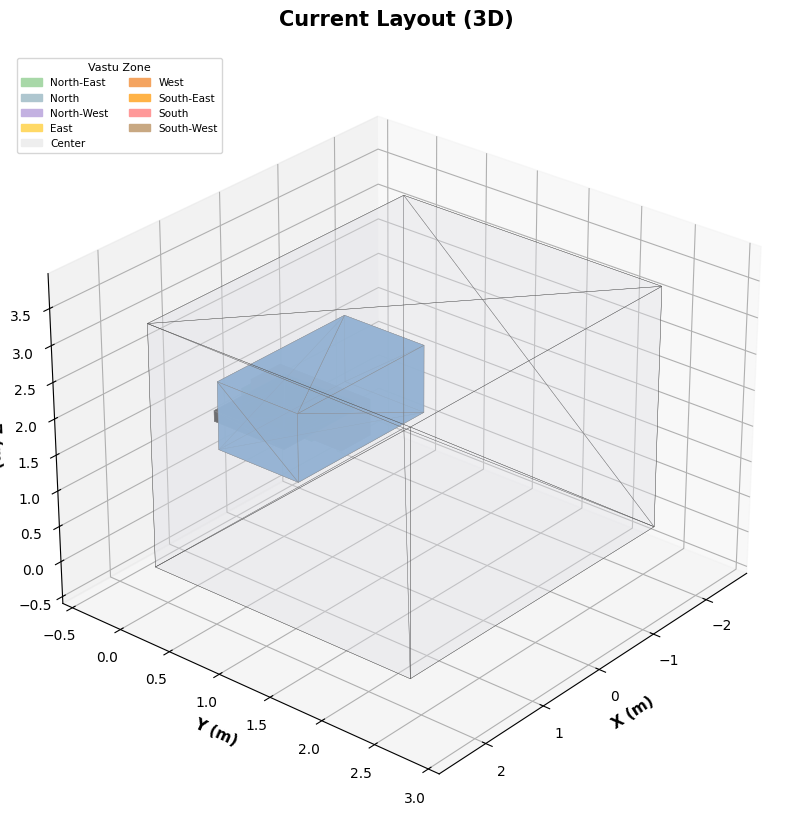

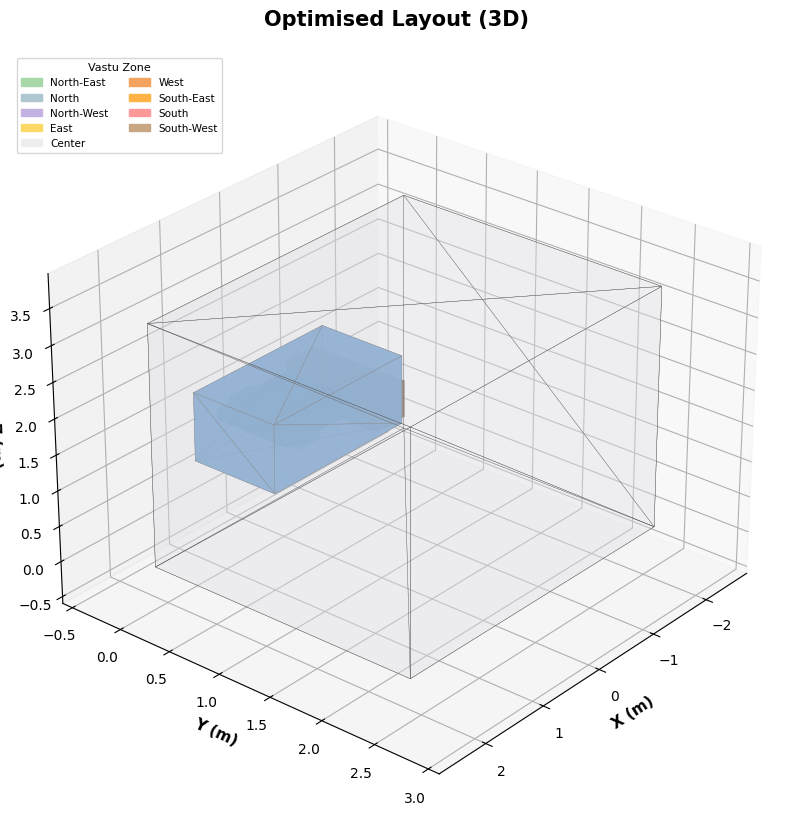

3D renders saved


In [ ]:
ZONE_3D_COLORS = {
    'North-East':'#a8d8a8','North':'#aec6cf','North-West':'#c3b1e1',
    'East':'#ffd966','Center':'#eeeeee','West':'#f4a460',
    'South-East':'#ffb347','South':'#ff9999','South-West':'#c8a882',
}

def visualize_3d_scene(scene, title, objs_dict, save_path=None):
    fig = plt.figure(figsize=(15, 10))
    ax  = fig.add_subplot(111, projection='3d')
    for name, mesh in scene.geometry.items():
        if not len(mesh.vertices): continue
        fv = mesh.vertices[mesh.faces]
        if name == 'room':
            color = [0.88, 0.88, 0.90, 0.22]
        else:
            try:
                c = mesh.visual.face_colors[0][:4]/255.0
                color = [float(c[0]), float(c[1]), float(c[2]), 0.80]
            except:
                color = [0.7, 0.7, 0.7, 0.80]
        poly = Poly3DCollection(fv, facecolor=color[:3], edgecolor='#555555',
                                linewidth=0.25, alpha=color[3])
        ax.add_collection3d(poly)
    all_v = np.vstack([m.vertices for m in scene.geometry.values() if len(m.vertices)])
    pad = 0.6
    ax.set_xlim(all_v[:,0].min()-pad, all_v[:,0].max()+pad)
    ax.set_ylim(all_v[:,1].min()-pad, all_v[:,1].max()+pad)
    ax.set_zlim(all_v[:,2].min()-pad, all_v[:,2].max()+pad)
    ax.set_xlabel('X (m)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Y (m)', fontsize=11, fontweight='bold')
    ax.set_zlabel('Z (m)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    ax.view_init(elev=28, azim=40)
    patches = [mpatches.Patch(color=c, label=z) for z,c in ZONE_3D_COLORS.items()]
    ax.legend(handles=patches, loc='upper left', fontsize=7.5, ncol=2,
              title='Vastu Zone', title_fontsize=8)
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig, ax

print('Rendering 3D scenes...')
visualize_3d_scene(current_scene, 'Current Layout (3D)', objects_3d,
                   OUTPUT_DIR+'/renders/current_3d_view.png')
plt.show()
visualize_3d_scene(optimized_scene, 'Optimised Layout (3D)', optimized_objects_3d,
                   OUTPUT_DIR+'/renders/optimized_3d_view.png')
plt.show()
print('3D renders saved')

## Part 13: Final Recommendations with Vastu Rationale

In [ ]:
recommendations = []
changes_needed  = 0

print('\n' + '='*75)
print('FINAL VASTU RECOMMENDATIONS')
print('='*75)

for name in stabilized_objects:
    old_zone = stabilized_objects[name]['zone']
    new_zone = optimized_objects_3d[name]['zone']
    old_pos  = objects_3d[name]['position_3d']
    new_pos  = optimized_objects_3d[name]['position_3d']
    dist     = float(np.linalg.norm(np.array(new_pos)-np.array(old_pos)))
    needs    = old_zone != new_zone
    if needs: changes_needed += 1
    rationale = VASTU_RULES_FULL.get(name, {}).get('rationale', 'General Vastu guidance.')
    recommendations.append(dict(
        object=name, current_zone=old_zone, recommended_zone=new_zone,
        current_position_3d=[float(x) for x in old_pos],
        recommended_position_3d=[float(x) for x in new_pos],
        movement_distance_m=dist, action_needed=needs,
        vastu_rationale=rationale))
    if needs:
        print('\n[MOVE] ' + name.upper())
        print('   Current -> ' + old_zone + '   Recommended -> ' + new_zone)
        print('   Distance: ' + str(round(dist,2)) + ' m')
        print('   Rationale: ' + rationale[:130] + '...')
    else:
        print('\n[OK]   ' + name.upper() + ' -- optimal in ' + old_zone)

print('\n' + '='*75)
print('Objects to reposition: ' + str(changes_needed) + '/' + str(len(stabilized_objects)))
print('Violations: ' + str(violations) + ' -> ' + str(opt_violations))
n_obj = max(len(stabilized_objects),1)
print('Compliance: ' + str(round((1-opt_violations/n_obj)*100,1)) + '%')
print('='*75)


FINAL VASTU RECOMMENDATIONS

[OK]   VASE -- optimal in East

[OK]   TV -- optimal in East

[MOVE] COUCH
   Current -> South   Recommended -> East
   Distance: 0.8 m
   Rationale: Same as sofa. Couches are lighter seating and should remain in the energetically active Northern arc to promote conversation and p...

[MOVE] CHAIR
   Current -> South   Recommended -> West
   Distance: 0.62 m
   Rationale: Work chairs face East (rising Sun, concentration) or North (Kuber, prosperity). West is acceptable for reading where natural light...

[OK]   POTTED PLANT -- optimal in East

[OK]   CLOCK -- optimal in North

Objects to reposition: 2/6
Violations: 2 -> 0
Compliance: 100.0%


## Part 14: Export JSON, HTML Report & Model

In [ ]:
# JSON results
results = {
    'video_info': {k: video_info[k] for k in
                   ('filename','path','width','height','fps','duration','is_panoramic')},
    'camera_params': {k:v for k,v in camera_params.items() if isinstance(v,(int,float,bool))},
    'room_dimensions': dict(width_m=float(room_dimensions[0]),
                             depth_m=float(room_dimensions[1]),
                             height_m=float(room_dimensions[2])),
    'detected_objects': len(stabilized_objects),
    'initial_violations': int(violations),
    'optimized_violations': int(opt_violations),
    'improvement_pct': float((violations-opt_violations)/max(violations,1)*100),
    'recommendations': recommendations,
    'ga_stats': dict(generations=GA_GENERATIONS, population_size=GA_POPULATION,
                     initial_fitness=float(fitness_history[0]),
                     final_fitness=float(fitness_history[-1]),
                     improvement=float(fitness_history[0]-fitness_history[-1])),
}
with open(OUTPUT_DIR+'/data/complete_results.json','w') as f:
    json.dump(results, f, indent=2)
print('JSON -> ' + OUTPUT_DIR + '/data/complete_results.json')

# HTML report
rows = ''
for r in recommendations:
    status = 'OK' if not r['action_needed'] else 'MOVE'
    dist   = str(round(r['movement_distance_m'],2))+' m' if r['action_needed'] else '-'
    rat    = r.get('vastu_rationale','')[:150] + ('...' if len(r.get('vastu_rationale',''))>150 else '')
    clr    = '#d32f2f' if r['action_needed'] else '#388e3c'
    rows  += ('<tr><td><strong>'+r['object']+'</strong></td>'
              '<td>'+r['current_zone']+'</td>'
              '<td>'+r['recommended_zone']+'</td>'
              '<td>'+dist+'</td>'
              '<td style="color:'+clr+'">'+status+'</td>'
              '<td style="font-size:11px;color:#555">'+rat+'</td></tr>')

comp_pct = round((1-opt_violations/max(len(stabilized_objects),1))*100,0)
html = ('<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">'
        '<title>Vastu 3D Report</title>'
        '<style>'
        'body{font-family:system-ui,sans-serif;max-width:1200px;margin:0 auto;padding:24px;background:#f5f5f5;color:#222}'
        'h1{color:#2c5aa0;border-bottom:2px solid #2c5aa0;padding-bottom:8px}'
        '.kpi{display:flex;gap:16px;flex-wrap:wrap;margin:16px 0}'
        '.kpi-card{background:#fff;border-radius:10px;padding:16px 24px;box-shadow:0 1px 4px #0002;min-width:140px;text-align:center}'
        '.kpi-card .val{font-size:28px;font-weight:700;color:#2c5aa0}'
        '.kpi-card .lbl{font-size:12px;color:#666;margin-top:4px}'
        'table{width:100%;border-collapse:collapse;background:#fff;border-radius:10px;overflow:hidden;box-shadow:0 1px 4px #0002;margin-top:16px}'
        'th{background:#2c5aa0;color:#fff;padding:10px 12px;text-align:left;font-size:13px}'
        'td{padding:9px 12px;border-bottom:1px solid #eee;font-size:13px;vertical-align:top}'
        'tr:last-child td{border-bottom:none} tr:hover td{background:#f0f4ff}'
        '.footer{margin-top:32px;font-size:11px;color:#999;text-align:center}'
        '</style></head><body>'
        '<h1>Vastu 3D Analysis Report</h1>'
        '<p style="color:#555">Video: <strong>'+video_info['filename']+'</strong> | '
        'Generated: '+datetime.datetime.now().strftime('%Y-%m-%d %H:%M')+'</p>'
        '<div class="kpi">'
        '<div class="kpi-card"><div class="val">'+str(len(stabilized_objects))+'</div><div class="lbl">Objects detected</div></div>'
        '<div class="kpi-card"><div class="val">'+str(violations)+'</div><div class="lbl">Initial violations</div></div>'
        '<div class="kpi-card"><div class="val">'+str(opt_violations)+'</div><div class="lbl">After optimisation</div></div>'
        '<div class="kpi-card"><div class="val">'+str(int(comp_pct))+'%</div><div class="lbl">Final compliance</div></div>'
        '<div class="kpi-card"><div class="val">'+str(round(room_dimensions[0],1))+'x'+str(round(room_dimensions[1],1))+'m</div><div class="lbl">Room size</div></div>'
        '<div class="kpi-card"><div class="val">'+str(GA_GENERATIONS)+'</div><div class="lbl">GA generations</div></div>'
        '</div>'
        '<table><thead><tr>'
        '<th>Object</th><th>Current zone</th><th>Recommended</th>'
        '<th>Distance</th><th>Status</th><th>Vastu rationale</th>'
        '</tr></thead><tbody>'+rows+'</tbody></table>'
        '<div class="footer">Vastu 3D Pipeline v2.0 | YOLOv8 + MiDaS + GA</div>'
        '</body></html>')

html_path = OUTPUT_DIR+'/data/vastu_report.html'
with open(html_path, 'w') as f: f.write(html)
print('HTML report -> ' + html_path)

# Model
model_data = {
    'version': '2.0', 'created_at': datetime.datetime.now().isoformat(),
    'video_filename': video_info.get('filename', VIDEO_PATH),
    'vastu_rules': VASTU_RULES,
    'vastu_rules_full': {k: {'zones':v['zones'],'rationale':v['rationale']}
                         for k,v in VASTU_RULES_FULL.items()},
    'ga_config': dict(generations=GA_GENERATIONS, population_size=GA_POPULATION,
                      mutation_rate=0.3, mutation_sigma=0.15, elite_ratio=0.3),
    'fitness_weights': dict(vastu_penalty=10, movement_penalty=0.2,
                            overlap_penalty=5, min_separation=0.15),
    'training_history': dict(fitness_history=[float(f) for f in fitness_history],
                              initial_fitness=float(fitness_history[0]),
                              final_fitness=float(fitness_history[-1])),
    'best_layout': {obj:{'cx':float(p[0]),'cy':float(p[1])}
                    for obj,p in optimized_layout.items()},
    'statistics': dict(initial_violations=int(violations),
                       final_violations=int(opt_violations),
                       objects_optimized=len(stabilized_objects),
                       changes_needed=changes_needed),
}
pkl  = OUTPUT_DIR+'/data/vastu_ga_model.pkl'
jsnm = OUTPUT_DIR+'/data/vastu_ga_model.json'
with open(pkl,  'wb') as f: pickle.dump(model_data, f)
with open(jsnm, 'w')  as f: json.dump(model_data, f, indent=2)
print('Model -> ' + pkl + '  (' + str(round(os.path.getsize(pkl)/1024,1)) + ' KB)')
print('Model -> ' + jsnm)
print('\n' + '='*60)
print('ALL OUTPUTS SAVED')
print('='*60)
print('  ' + OUTPUT_DIR + '/visualizations/  -- all charts & plots')
print('  ' + OUTPUT_DIR + '/renders/         -- 3D view images')
print('  ' + OUTPUT_DIR + '/3d_models/       -- GLB / OBJ files')
print('  ' + OUTPUT_DIR + '/data/            -- JSON, HTML, model')
print('Pipeline complete!')

JSON -> vastu_3d_results/data/complete_results.json
HTML report -> vastu_3d_results/data/vastu_report.html
Model -> vastu_3d_results/data/vastu_ga_model.pkl  (8.6 KB)
Model -> vastu_3d_results/data/vastu_ga_model.json

ALL OUTPUTS SAVED
  vastu_3d_results/visualizations/  -- all charts & plots
  vastu_3d_results/renders/         -- 3D view images
  vastu_3d_results/3d_models/       -- GLB / OBJ files
  vastu_3d_results/data/            -- JSON, HTML, model
Pipeline complete!
